In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.columns = df.columns.str.strip()

y = df['fraud_label']
X = df.drop(columns=['fraud_label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [5]:
preprocessor = joblib.load("../models/preprocessor.pkl")
model = joblib.load("../models/xgboost_model.pkl")

X_test_processed = preprocessor.transform(X_test)

y_prob = model.predict_proba(X_test_processed)[:, 1]


In [6]:
FRAUD_LOSS = 500          # Loss per missed fraud (False Negative)
FALSE_DECLINE_COST = 25   # Customer friction cost (False Positive)
INVESTIGATION_COST = 5    # Manual review cost (TP + FP)

In [8]:
thresholds = np.arange(0.1, 0.91, 0.1)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    fraud_cost = fn * FRAUD_LOSS
    false_decline_cost = fp * FALSE_DECLINE_COST
    investigation_cost = (tp + fp) * INVESTIGATION_COST
    
    total_cost = fraud_cost + false_decline_cost + investigation_cost
    
    results.append([threshold, fn, fp, tp, total_cost])

cost_df = pd.DataFrame(results, columns=[
    "Threshold", "False Negatives", "False Positives", "True Positives", "Total Cost"
])

cost_df


,Threshold,False Negatives,False Positives,True Positives,Total Cost
0,0.1,0,47378,2771,1435195
1,0.2,114,31276,2657,1008565
2,0.3,120,31104,2651,1006375
3,0.4,363,25146,2408,947920
4,0.5,494,22413,2277,930775
5,0.6,1451,9905,1320,1029250
6,0.7,2244,2804,527,1208755
7,0.8,2721,187,50,1366360
8,0.9,2771,0,0,1385500


In [10]:
optimal_row = cost_df.loc[cost_df["Total Cost"].idxmin()]

optimal_row


Threshold               0.5
False Negatives       494.0
False Positives     22413.0
True Positives       2277.0
Total Cost         930775.0
Name: 4, dtype: float64

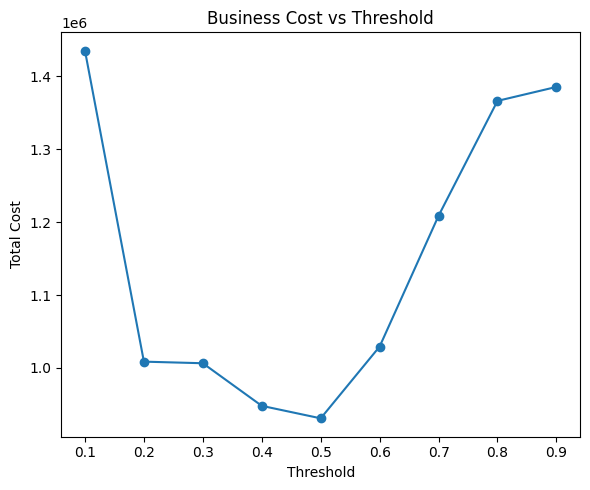

In [12]:
plt.figure(figsize=(6,5))

plt.plot(cost_df["Threshold"], cost_df["Total Cost"], marker='o')

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Business Cost vs Threshold")

plt.tight_layout()
plt.savefig("../reports/figures/cost_vs_threshold.png")

plt.show()


In [13]:
cost_df.to_csv("../reports/business_cost_summary.csv", index=False)
